# Internal Event Reporting

## Overview

In this tutorial, we will explore mechanism that allow components to **report events that occur within their internal micro-stepping**.
This will allow the hybrid algorithm to accurately detect and localize events that would otherwise be missed between communication points.

![Internal Event Reporting Diagram](figures/event_reporting.svg)


## Learning Goals

- Understand the concept of hybrid systems and event-driven simulation.
- Learn how to implement event detection and handling in co-simulation components.
- Explore the use of the hybrid co-simulation algorithm to manage events during simulation.

## Prerequisites and Setup

Before starting this tutorial, ensure you have completed the previous tutorials, especially Tutorial 1 on implementing a simple pendulum as a co-simulation component.
Familiarity with the basic concepts of co-simulation and the system simulation framework is essential.
Make sure you have the latest version of the SystemSimulation framework installed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from syssimx.core.base import CoSimComponent
from syssimx.core.events import Event
from syssimx.core.port import PortSpec, PortType
from syssimx.system.connection import EventConnection
from syssimx.system.system import System
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

## Motivation

We have learned that state events are detected by evaluating event indicator functions at communication points.
However, if an event occurs between two communication points, it may be missed entirely.
To address this, we will implement a mechanism that allows components to report events that occur within their internal micro-stepping.

Consider the following zero-crossing event indicator function:

$$h(t) = (t - 0.45)(t - 0.55)$$

This function has two roots at $t_1 = 0.45 \, \mathrm{s}$ and $t_2 = 0.55 \, \mathrm{s}$.

In [2]:
h = lambda t: (t-0.45) * (t-0.55)
t = np.linspace(0, 1, 100)
t_macro = np.arange(0, 1.2, 0.2)

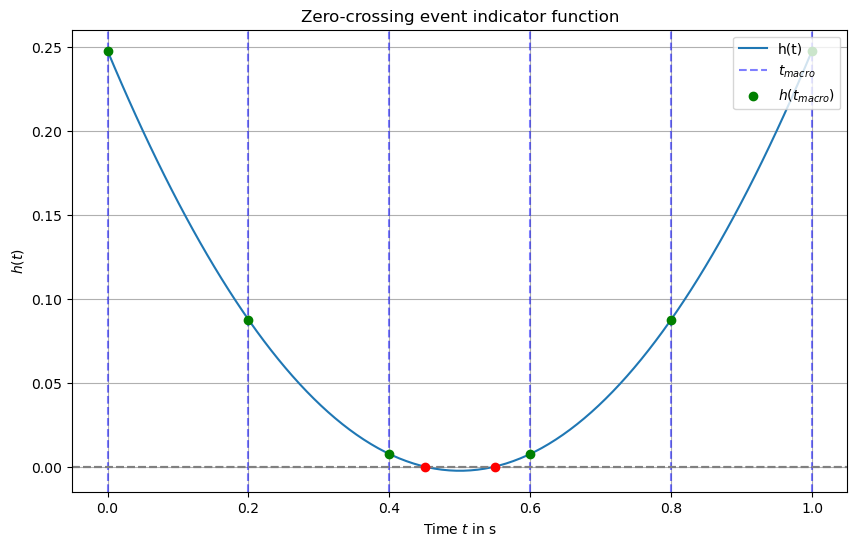

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(t, h(t), label='h(t)')
for tm in t_macro:
    plt.axvline(tm, color='blue', linestyle='--', alpha=0.5, label=r'$t_{macro}$' if tm == 0 else "")
plt.scatter([0.45, 0.55], [0, 0], color='red', zorder=5)
plt.scatter(t_macro, h(t_macro), color='green', zorder=5, label=r'$h(t_{macro})$')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"$h(t)$")
plt.title('Zero-crossing event indicator function')
plt.axhline(y=0, color="gray", linestyle="--")
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

It can be seen that the event occurs between two communication points at $t=0.4\, \mathrm{s}$ and $t=0.6\, \mathrm{s}$.

The event would be missed if we only evaluate the event indicator function at communication points.

To solve this problem, we will implement a mechanism that allows components to report events that occur within their internal micro-stepping.

## Implement Component with Event Reporting

We will create a event reporting component that simulates a signal which crosses zero at specific times $T_1$ and $T_2$.

$$h(t) = (t - T_1) (t - T_2)$$

The state variable `h` will be used as the event indicator function. It crosses zero at times `T1` and `T2`.
In order to report events internally, the component tracks the previous value of `h` (`h_prev`) to detect zero-crossings during its internal micro-steps.

The `_do_step_internal` method uses an internal micro-step size `dt_internal` to advance the simulation time and check for zero-crossings of `h`.
When a zero-crossing is detected, the component records an internal event hint, which will be used by the hybrid co-simulation algorithm to handle the event appropriately.

In [16]:
class EventReportingComponent(CoSimComponent):
    def __init__(self, name: str, T1: float, T2: float) -> None:
        super().__init__(name, group="Sources")
        
        self.dt_internal = 0.01
        self.h = 0.0
        self.h_prev = 0.0

        self.T1 = T1
        self.T2 = T2

        self.output_specs.update({"h": PortSpec(name="h", type=PortType.REAL, direction="out")})
    
    def _initialize_component(self, t0: float) -> None:
        self._initialize_ports_from_specs()
        self.h = (self.t - self.T1) * (self.t - self.T2)
        self.h_prev = self.h

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.internal_event_hints.clear()

        if dt < self.dt_internal - 1e-12:
            effective_dt = dt
        else:
            effective_dt = self.dt_internal

        t_current = t
        t_end = t + dt

        while t_current < t_end - 1e-12:
            step_size = min(effective_dt, t_end - t_current)

            self.h_prev = self.h
            t_prev = t_current

            t_current += step_size
            self.t = t_current
            self.h = (self.t - self.T1) * (self.t - self.T2)

            self._update_output_states(t=self.t)
            self._record_outputs(t=self.t)

            # Check for zero-crossing event
            if self.h_prev * self.h < 0:
                self.report_internal_event(
                    event_name="zero_crossing",
                    t_before=t_prev,  # self.t - self.dt_internal,
                    t_after=t_current,
                    indicator_before=self.h_prev,
                    indicator_after=self.h,
                )

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["h"].set(self.h, t=t)

    def snapshot_state(self):
        return {"t": self.t, "h": self.h, "h_prev": self.h_prev}

    def restore_state(self, snapshot, t: float | None = None) -> None:
        self.t = snapshot["t"]
        self.h = snapshot["h"]
        self.h_prev = snapshot.get("h_prev", self.h)
        # Clear internal hints on restore - they're no longer valid
        self.internal_event_hints.clear()

    def reset(self) -> None:
        super().reset()
        self.h = 0.0
        self.h_prev = 0.0

## Implement Event Listener Component

The event listener component has a linear evolving state variable `x`.

It starts at an initial value `x0` and increases linearly over time with a slope of `v`.

The component subscribes to the zero-crossing event reported by the event reporting component. When the event is triggered, the listener component handles it by inverting the sign of its slope `v`, effectively changing the direction of its linear evolution.

In [17]:
class EventListenerComponent(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0
        self.v = v
        self.t0 = t0

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self.input_specs.update(
            {"v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in")}
        )
        self._initialize_ports_from_specs()

    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _update_output_states(
        self, t: float | None = None, event_names: list[str] | None = []
    ) -> None:
        self.outputs["x"].set(self.x, t=t)

    def _handle_events_internal(self, event_names, t):
        if "zero_crossing" in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from {-self.v} to {self.v}")

    def reset(self) -> None:
        super().reset()
        self.x0 = 0.0
        self.v = 1.0
        self.t0 = 0.0

## Create Hybrid Co-Simulation System

The event reoporting component and event listener component are instantiated.

An event indicator function is defined for the event reporting component, which is simply the output `h` of the component.
This event indicator function is used by the hybrid co-simulation algorithm to detect zero-crossing events at communication points $t_{macro}$.

The event indicator is added to the event reporting component with `direction=0`, indicating that we are interested in detecting both upward and downward zero-crossings.

In [18]:
# 1) Create components
event_reporter = EventReportingComponent(name="EventReporter", T1=0.45, T2=0.55)
event_listener = EventListenerComponent(name="EventListener", x0=0.0, v=0.25)

# 2) Define event indicator functions
def event_indicator_function(comp: EventReportingComponent) -> float:
    return comp.h

# 3) Add event indicators to source components
event_reporter.add_event_indicator(
    name="zero_crossing", func=event_indicator_function, direction=0
)

We create a system and add both components to it.

An event connection is defined to link the event reported by the event reporting component to the event listener component.
- The `scr_port` is set to `"zero_crossing"`, which is the name of the event defined earlier.
- The `dst_port` is set to `"v_invert"`, which is the name of the input port in the event listener component that handles the event.

The event connection is added to the system to establish the link between the two components.

In [19]:
import logging

logging.basicConfig(
    level=logging.WARNING,  # keep third-party loggers quiet
    format="[%(module)s] %(levelname)s: %(message)s",
)
# Enable debug output for the syssimx package
logging.getLogger("syssimx").setLevel(logging.DEBUG)

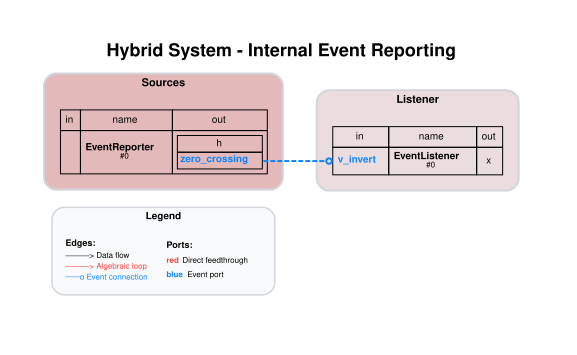

In [20]:
# 7) Create system
system = System(name="Hybrid System - Internal Event Reporting")

# 8) Add components to system
system.add_component(event_reporter)
system.add_component(event_listener)

# 9) Create and add event connections to the system
connection = EventConnection(
    src_comp=event_reporter.name,
    src_port="zero_crossing",
    dst_comp=event_listener.name,
    dst_port="v_invert",
)
system.add_event_connection(connection)

# 10) Initialize and run the system
system.initialize(t0=0.0)

# 11) Create system graph visualization
sys_viz = SystemGraphVisualizer(system=system)
sys_viz.visualize()


Since we have an event reporting component and an event listener component, we will use the `HybridAlgorithm` to manage the co-simulation process.

In [21]:
print("Component Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")
print(f"\nUsing Algorithm: {system.algorithm.name}\n")

Component Classification:
 - event_sources: ['EventReporter']
 - event_listeners: ['EventListener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm



## Run the Hybrid System with Internal Event Reporting

In [22]:
# 12) Run the simulation
system.run(t0=0.0, tf=1.0, dt=0.2)

[hybrid] DEBUG: Internal hint: EventReporter.zero_crossing in [0.44000000, 0.45000000]
[hybrid] DEBUG: Internal hint: EventReporter.zero_crossing in [0.54000000, 0.55000000]
[hybrid] INFO: ================================================================================
[hybrid] INFO: Event crossing in [0.400000, 0.600000]: EventReporter.zero_crossing
[hybrid] DEBUG:   Internal hints from EventReporter: ['zero_crossing', 'zero_crossing']
[hybrid] DEBUG: Starting bisection for event localization ...
[hybrid] DEBUG: Narrowed interval via hint: [0.400000, 0.600000] -> [0.440000, 0.450000]
[hybrid] DEBUG: Indicators at left  (t=0.44000000): {'EventReporter': {'zero_crossing': 0.0010999999999999946}}
[hybrid] DEBUG: Indicators at right (t=0.45000000): {'EventReporter': {'zero_crossing': -5.5511151231257815e-18}}
[hybrid] DEBUG: Indicator EventReporter.zero_crossing = -5.5511e-18
[hybrid] INFO: Event located at t=0.45000000
[hybrid] DEBUG:   Events at located time: EventReporter.zero_crossing

EventListener handled event at t=0.4500: v inverted from 0.25 to -0.25
EventListener handled event at t=0.5500: v inverted from -0.25 to 0.25


The output shows that the event reporting component successfully detects and reports the zero-crossing events at `t=0.45s` and `t=0.55s`.

The hybrid co-simulation algorithm handles these events by using the internal event hints provided by the event reporting component.

Since the events occur at boundaries of micro-steps, the algorithm is able to accurately localize and handle them.
The algorithm ensures that each event is processed correctly and only once, preventing duplicate handling of the same event.

## Retrieve and Plot Results

We can extract again the histories for the components and the event history from the hybrid co-simulation result.

The output shows that the event reporting component detected two zero-crossing events approx. at `t=0.45s` and `t=0.55s`.

In [23]:
time_reporter, history_reporter = event_reporter.get_history_arrays()
h_reporter = history_reporter["h"]

time_listener, history_listener = event_listener.get_history_arrays()
x_listener = history_listener["x"]

event_history = system.history.get_all_event_histories()
trigger_times = event_history.get((event_reporter.name, "zero_crossing"), [])
trigger_time_1 = trigger_times[0].t
trigger_time_2 = trigger_times[1].t

for event_key, events in event_history.items():
    print(f"\nEvents for {event_key}:")
    for event in events:
        print(f" - Event at t={event.t}")


Events for ('EventReporter', 'zero_crossing'):
 - Event at t=0.45000000000000007
 - Event at t=0.550000000463257


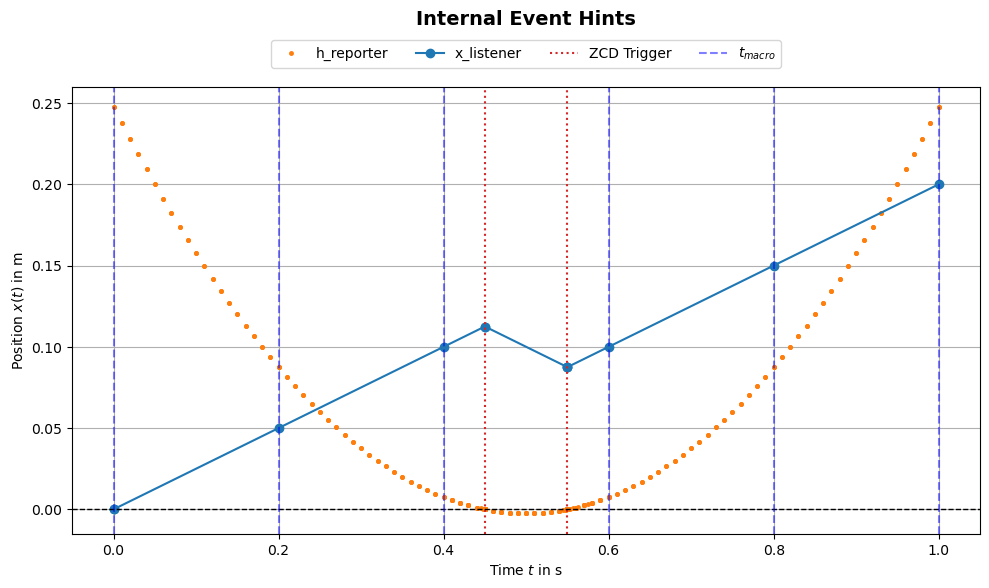

In [24]:
plt.figure(figsize=(10, 6))
plt.plot( time_reporter, h_reporter, label="h_reporter", color="tab:orange", linestyle="None", marker=".", markersize=5,)
plt.plot(time_listener, x_listener, label="x_listener", color="tab:blue", marker="o", linestyle="-")
plt.axvline(trigger_time_1, color="tab:red", linestyle=":", label="ZCD Trigger")
plt.axvline(trigger_time_2, color="tab:red", linestyle=":")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

communication_points = np.arange(0, 1.01, 0.2)
for i, cp in enumerate(communication_points):
    plt.axvline(cp, color='blue', linestyle='--', alpha=0.5, label=r'$t_{macro}$' if i == 0 else "")

plt.title("Internal Event Hints", fontsize=14, fontweight="bold", y=1.12)
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Position $x(t)$ in m")
plt.grid()
plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.show()

The figure shows that the event listener component's state variable `x` changes its slope at the times when the zero-crossing events are detected, demonstrating that the events were successfully handled during the co-simulation.

The figure also shows the communication time steps used during the hybrid co-simulation. At these time points, the event indicator function of the event reporting component is evaluated to check for events. For our event reporting component, the events were detected between communication points, thanks to the internal event reporting mechanism.

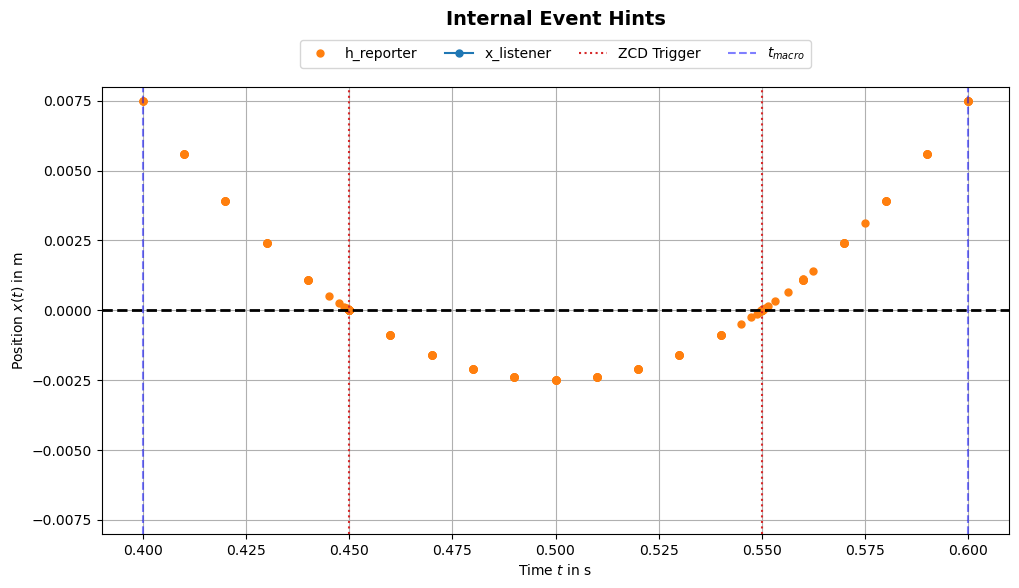

In [25]:
plt.figure(figsize=(10, 6))
plt.plot( time_reporter, h_reporter, label="h_reporter", color="tab:orange", linestyle="None", marker="o", markersize=5,)
plt.plot(time_listener,x_listener,label="x_listener",color="tab:blue",linestyle="-",marker="o",markersize=5,)
plt.axvline(trigger_time_1, color="tab:red", linestyle=":", label="ZCD Trigger")
plt.axvline(trigger_time_2, color="tab:red", linestyle=":")

plt.axhline(0, color="black", linestyle="--", linewidth=2)
communication_points = np.arange(0, 1.01, 0.2)
for i, cp in enumerate(communication_points):
    plt.axvline(cp, color='blue', linestyle='--', alpha=0.5, label=r'$t_{macro}$' if i == 0 else "")

plt.title("Internal Event Hints", fontsize=14, fontweight="bold", y=1.12)
plt.xlabel(r"Time $t$ in s")
plt.ylabel(r"Position $x(t)$ in m")
plt.grid()
plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.xlim(0.39, 0.61)
plt.ylim(-0.008, 0.008)
plt.yticks(np.arange(-0.0075, 0.008, 0.0025))
plt.xticks(np.arange(0.4, 0.6025, 0.025))
plt.show()

Close to the actual zero-crossing times, one can see that the algorithm used smaller communication step sizes to accurately localize the events.

-----------------------------

## Summary and Next Steps

In this tutorial, we explored the implementation of event reporting and handling in a hybrid co-simulation framework.
We created an event reporting component that detects zero-crossing events within its internal micro-stepping and an event listener component that responds to these events.
Using the hybrid co-simulation algorithm, we successfully managed the detection and handling of events during the simulation.

We will later use and see a concrete example of this mechanism in action for our `FEMPendulum` implementation.
This FEM pendulum model includes an internal contact mechanism with a wall. This contact event may be not detected at communication points, so the internal event reporting mechanism is crucial to accurately capture and handle these contact events during co-simulation.